In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('spam_ham_dataset.csv')
df.shape

(5171, 4)

In [2]:
df = df.drop(columns=['Unnamed: 0'])

df = df.drop_duplicates(subset='text').reset_index(drop=True)

df['label'].value_counts()

label
ham     3531
spam    1462
Name: count, dtype: int64

In [3]:
print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True) * 100)

label
ham     3531
spam    1462
Name: count, dtype: int64
label
ham     70.719007
spam    29.280993
Name: proportion, dtype: float64


In [4]:
df.shape

(4993, 3)

In [5]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(preprocess_text)
df[['text', 'clean_text']].head()

,text,clean_text
0,Subject: enron methanol ; meter # : 988291\r\n...,subject enron methanol meter follow note gave ...
1,"Subject: hpl nom for january 9 , 2001\r\n( see...",subject hpl nom january see attached file hpln...
2,"Subject: neon retreat\r\nho ho ho , we ' re ar...",subject neon retreat ho ho ho around wonderful...
3,"Subject: photoshop , windows , office . cheap ...",subject photoshop window office cheap main tre...
4,Subject: re : indian springs\r\nthis deal is t...,subject indian spring deal book teco pvr reven...


In [6]:
df[['label', 'label_num']].drop_duplicates()

,label,label_num
0,ham,0
3,spam,1


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['label_num'], test_size=0.2, random_state=42, stratify=df['label_num']
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

(3994,) (999,)
label_num
0    2825
1    1169
Name: count, dtype: int64
label_num
0    706
1    293
Name: count, dtype: int64


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape, X_test_tfidf.shape)

(3994, 5000) (999, 5000)


In [9]:
len(tfidf.get_feature_names_out())

5000

In [10]:
tfidf_full = TfidfVectorizer()
tfidf_full.fit(X_train)
print(len(tfidf_full.get_feature_names_out()))

37624


In [11]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_preds = nb_model.predict(X_test_tfidf)

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)
lr_preds = lr_model.predict(X_test_tfidf)

print("Naive Bayes")
print(classification_report(y_test, nb_preds))
print("\nLogistic Regression")
print(classification_report(y_test, lr_preds))

Naive Bayes
              precision    recall  f1-score   support

           0       0.98      0.95      0.97       706
           1       0.89      0.96      0.92       293

    accuracy                           0.95       999
   macro avg       0.94      0.95      0.95       999
weighted avg       0.96      0.95      0.95       999


Logistic Regression
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       706
           1       0.94      0.98      0.96       293

    accuracy                           0.98       999
   macro avg       0.97      0.98      0.97       999
weighted avg       0.98      0.98      0.98       999



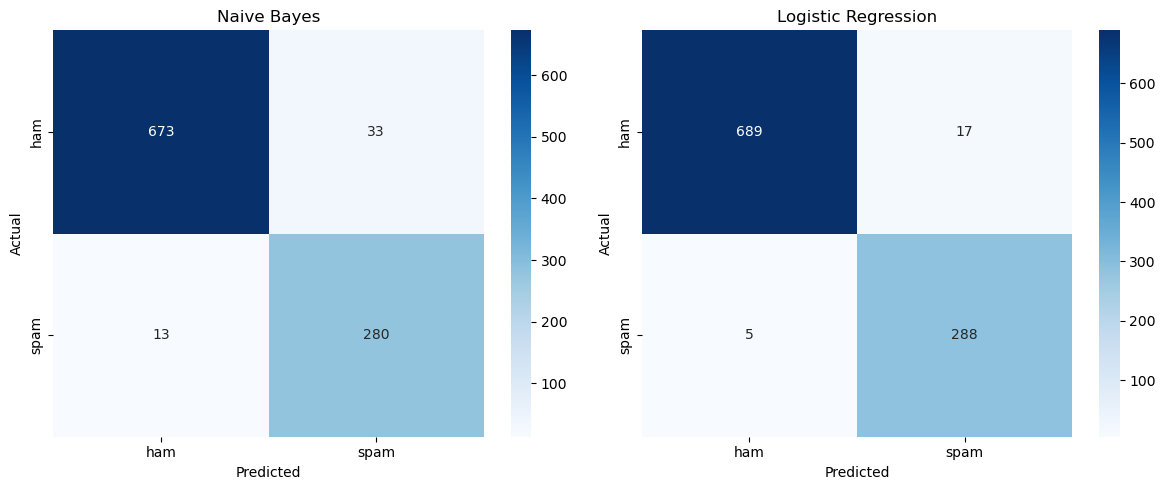

In [12]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_nb = confusion_matrix(y_test, nb_preds)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
axes[0].set_title('Naive Bayes')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_lr = confusion_matrix(y_test, lr_preds)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
axes[1].set_title('Logistic Regression')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

### Why TF-IDF over raw word counts

TF-IDF weights a word by how often it appears in a given email (term frequency) 
discounted by how common it is across the whole corpus (inverse document frequency).

A word like "subject" appears in nearly every email, high term frequency, but 
zero discriminating power. IDF pushes its weight toward zero automatically.

A word like "viagra" is rare corpus-wide but concentrated in a handful of spam 
emails, high TF-IDF score, strong signal.

This is why TF-IDF beats raw counts for this task: it surfaces words that are 
locally frequent but globally rare, without needing a hand-curated stopword 
list for domain-specific noise like the "Subject:" prefix every row in this 
dataset carries.

### Recall vs. precision for spam filtering

A false negative (spam reaching the inbox) costs the user a few seconds, 
they see junk, they delete it.

A false positive (real email flagged as spam) can cost far more, and most users 
don't check their spam folder regularly, so a misclassified email risks being 
missed entirely.

That asymmetry is why recall is generally prioritized over precision in spam 
detection: missing spam is cheap, missing real mail isn't.

On this dataset the two models don't force a hard trade-off, Logistic 
Regression leads on both precision (0.94 vs 0.89) and recall (0.98 vs 0.96) 
for the spam class, and misses fewer real spam emails (5 vs 13 false 
negatives) while flagging fewer legitimate emails as spam (17 vs 33 false 
positives). Naive Bayes remains the standard baseline for text classification, 
but here Logistic Regression is the better-performing choice on the metric 
that matters most.

In [13]:
!pip install wordcloud --quiet

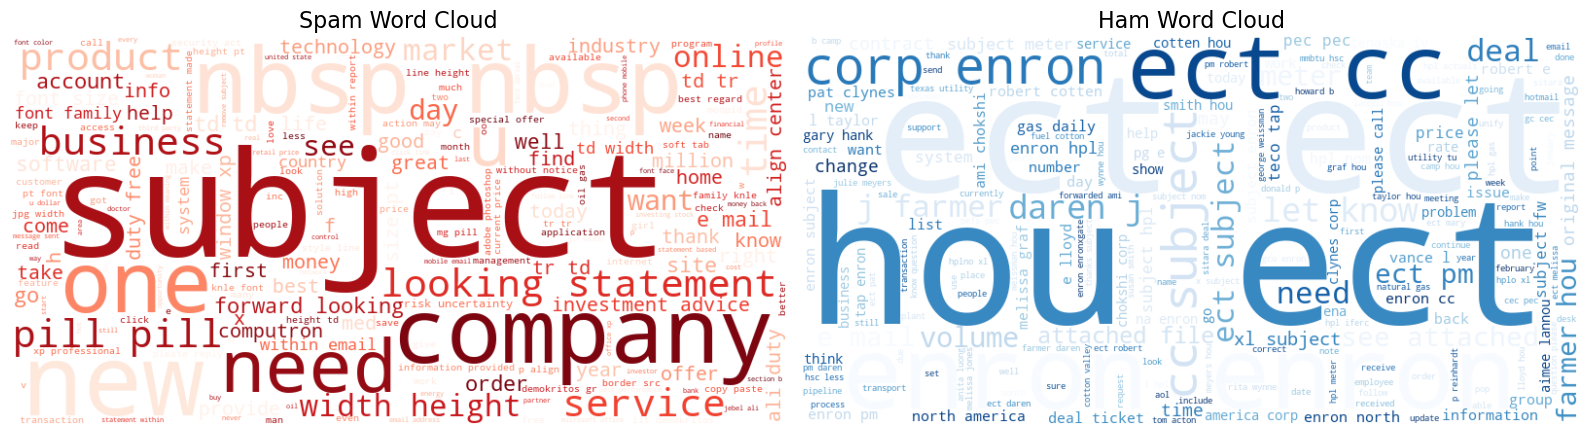

In [14]:
from wordcloud import WordCloud

spam_text = ' '.join(df[df['label_num'] == 1]['clean_text'])
ham_text = ' '.join(df[df['label_num'] == 0]['clean_text'])

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

wc_spam = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(spam_text)
axes[0].imshow(wc_spam, interpolation='bilinear')
axes[0].set_title('Spam Word Cloud', fontsize=16)
axes[0].axis('off')

wc_ham = WordCloud(width=800, height=400, background_color='white', colormap='Blues').generate(ham_text)
axes[1].imshow(wc_ham, interpolation='bilinear')
axes[1].set_title('Ham Word Cloud', fontsize=16)
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Word cloud observations

Word clouds are frequency-based, not TF-IDF weighted unlike the model, 
they don't automatically downweight common words. That's why "subject" 
dominates both clouds despite carrying no discriminating signal for 
classification.

The ham cloud is dominated by corpus-specific artifacts ("ect", "hou"), 
truncation patterns specific to this historical Enron email dataset, not 
meaningful English words.

The spam cloud is more informative: "pill", "product", "market", "software", 
"order" reflect genuine promotional/scam vocabulary, consistent with the 
pharmaceutical and pump-and-dump stock spam samples seen earlier in the data.

### Conclusion

Two classifiers were trained on TF-IDF features: Multinomial Naive Bayes 
(the standard baseline for text classification) and Logistic Regression.

| Model | Accuracy | Spam Precision | Spam Recall | False Negatives | False Positives |
|---|---|---|---|---|---|
| Naive Bayes | 0.95 | 0.89 | 0.96 | 13 | 33 |
| Logistic Regression | 0.98 | 0.94 | 0.98 | 5 | 17 |

**Logistic Regression is the better model here**, it leads Naive Bayes on 
every metric that matters for this task, missing fewer spam emails (5 vs 13) 
while also misclassifying fewer legitimate emails as spam (17 vs 33).

This dataset (enron-1 subset, ~5,000 emails, 71% ham / 29% spam) did not 
force a hard precision-recall trade-off between the two models, Logistic 
Regression won on both fronts simultaneously. On a noisier or larger dataset, 
that gap likely wouldn't hold as cleanly.

**Known limitations**, documented rather than hidden:
- Numeric content (prices, phone numbers) was stripped during preprocessing, 
  which may have discarded genuine spam signal
- TF-IDF was capped at 5,000 features out of ~37,600 unique terms in the 
  training vocabulary, dropping rare/long-tail words
- Lemmatization used default POS tagging (noun), so some verbs weren't 
  reduced to their true root form